In [ ]:
# Import necessary libraries
import yfinance as yf
from IPython.display import display, Markdown
import ipywidgets as widgets
import pandas as pd
import io
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:.3f}'.format


/Users/bc5176/Projects/Python/InvestHelper/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
def plot_sector_allocation(portfolio_df):
    # Group the data by sector and calculate the allocation percentage for each sector
    sector_allocation = portfolio_df.groupby('Sector')['Value'].sum()
    sector_allocation_percentage = (sector_allocation / portfolio_df['Value'].sum()) * 100
    
    # Plotting the pie chart
    plt.figure(figsize=(8, 8))
    plt.pie(sector_allocation_percentage, labels=sector_allocation_percentage.index, 
            autopct='%1.1f%%', startangle=140)
    plt.title("Portfolio Sector Allocation")
    plt.show()

In [3]:
def plot_sector_and_type_allocation(portfolio_df, high_dividend_threshold=2.0):
    """
    Plots two charts:
    1. Sector allocation as a pie chart.
    2. Type allocation (High Dividend Yield, Growth, ETFs) as a pie chart.

    Parameters:
        portfolio_df (pd.DataFrame): The portfolio data, including 'Sector' and 'Dividend Yield (%)'.
        high_dividend_threshold (float): The dividend yield percentage threshold to classify high dividend stocks.
    """
    import matplotlib.pyplot as plt
    
    # Sector Allocation
    sector_allocation = portfolio_df.groupby('Sector')['Value'].sum()
    sector_allocation_percentage = (sector_allocation / portfolio_df['Value'].sum()) * 100
    
    # Type Allocation
    def classify_stock(row):
        if row['Dividend Yield (%)'] >= high_dividend_threshold:
            return 'High Dividend Yield'
        elif row['Sector'] == 'ETF':
            return 'ETF'
        else:
            return 'Growth'

    portfolio_df['Type'] = portfolio_df.apply(classify_stock, axis=1)
    type_allocation = portfolio_df.groupby('Type')['Value'].sum()
    type_allocation_percentage = (type_allocation / portfolio_df['Value'].sum()) * 100
    
    # Plot both pie charts
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Sector allocation pie chart
    axes[0].pie(sector_allocation_percentage, labels=sector_allocation_percentage.index, 
                autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
    axes[0].set_title("Portfolio Sector Allocation")
    
    # Type allocation pie chart
    axes[1].pie(type_allocation_percentage, labels=type_allocation_percentage.index, 
                autopct='%1.1f%%', startangle=140, colors=plt.cm.tab10.colors)
    axes[1].set_title("Portfolio Type Allocation")
    
    plt.tight_layout()
    plt.show()

FileUpload(value=(), accept='.csv', description='Upload')

### Portfolio Allocation Analysis

,Symbol,Qty,Value,Allocation (%),Dividend Yield (%),Expected Annual Dividend,Sector
0,ACWI,60,7214.000,16.211,0.000,0.000,ETF
1,SPY,10,5978.500,13.434,0.000,0.000,ETF
2,GOOGL,20,3579.000,8.042,0.490,17.537,Communication Services
3,MSFT,8,3399.920,7.640,0.800,27.199,Technology
4,AAPL,15,3368.400,7.569,0.440,14.821,Technology
5,NVDA,22,3243.900,7.289,0.030,0.973,Technology
6,T,100,2232.000,5.016,4.790,106.913,Communication Services
7,QQQ,4,2050.800,4.608,0.000,0.000,ETF
8,KHC,60,1930.800,4.339,5.030,97.119,Consumer Defensive
9,EMGF,35,1645.000,3.697,0.000,0.000,ETF


### Portfolio Analysis Summary

**Total Portfolio Value**: 44501.210

**Total Expected Annual Dividend**: 473.372

**Portfolio Dividend Yield (%)**: 1.064

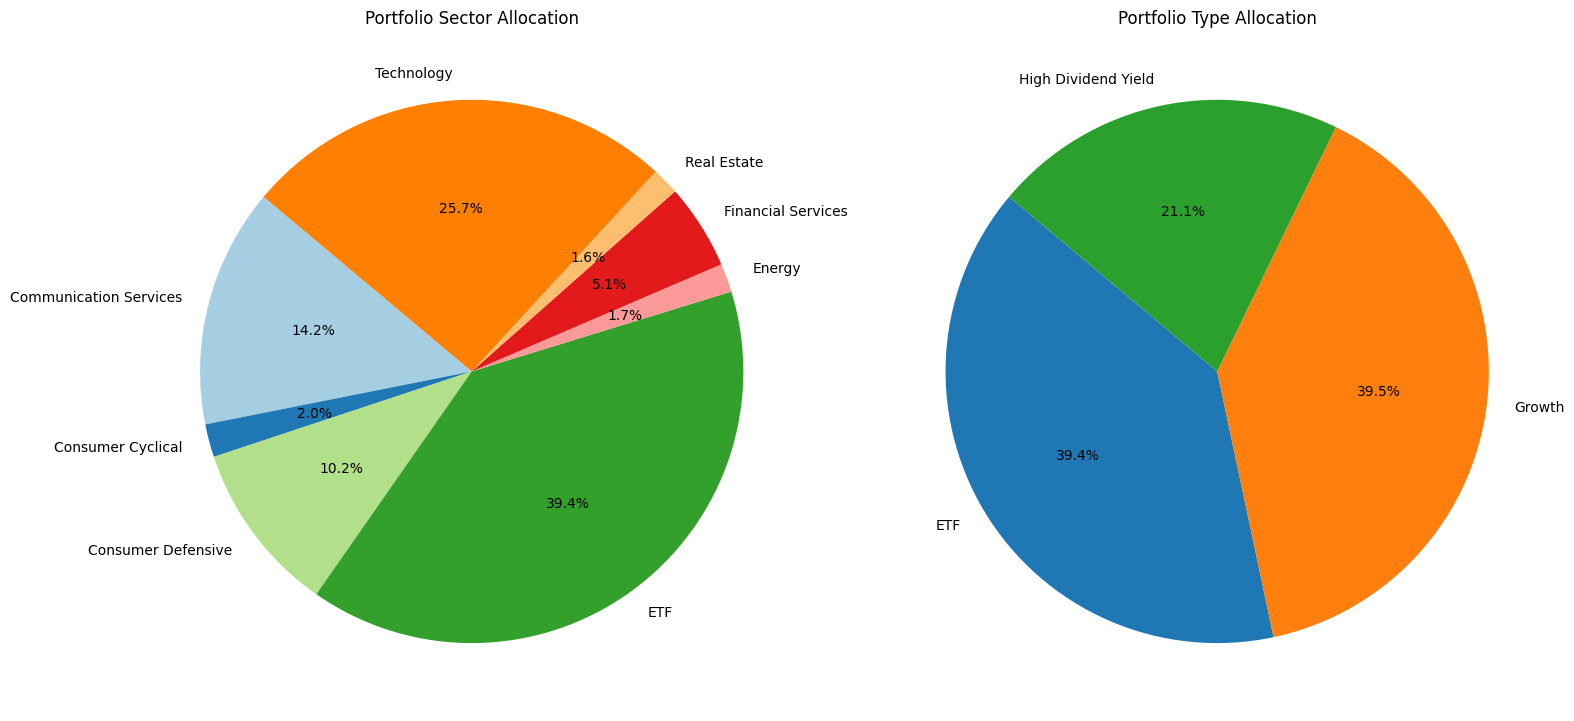

In [4]:
# Function to upload portfolio CSV

def upload_file():
    uploader = widgets.FileUpload(
        accept='.csv',  # Accepts .csv files only
        multiple=False  # Allows only one file upload
    )
    display(uploader)
    return uploader

# Function to load and process portfolio data
def process_portfolio(portfolio_df):
    
    # Ensure columns are as expected
    if not {'Symbol', 'Qty', 'Value'}.issubset(portfolio_df.columns):
        raise ValueError("CSV file must contain 'Symbol', 'Qty', and 'Value' columns.")
    
    # Retrieve stock information from yfinance
    portfolio_df['Dividend Yield (%)'] = 0.0
    portfolio_df['Sector'] = ''
    
    for i, row in portfolio_df.iterrows():
        ticker = yf.Ticker(row['Symbol'])
        try:
            # Get stock info and add it to the DataFrame
            info = ticker.info
            portfolio_df.at[i, 'Dividend Yield (%)'] = info.get('dividendYield', 0) * 100  # convert to percentage
            portfolio_df.at[i, 'Sector'] = info.get('sector', 'ETF')
        except:
            portfolio_df.at[i, 'Dividend Yield (%)'] = None
            portfolio_df.at[i, 'Sector'] = 'ETF'

    # Calculate Portfolio Allocation Analysis
    portfolio_df['Allocation (%)'] = (portfolio_df['Value'] / portfolio_df['Value'].sum()) * 100
    portfolio_df = portfolio_df.sort_values(by='Allocation (%)', ascending=False).reset_index(drop=True)


    # Dividend Yield Analysis
    portfolio_df['Expected Annual Dividend'] = (portfolio_df['Dividend Yield (%)'] / 100) * portfolio_df['Value']
    total_dividend_yield = portfolio_df['Expected Annual Dividend'].sum() / portfolio_df['Value'].sum() * 100

    # Risk Analysis - Sector Distribution
    sector_allocation = portfolio_df.groupby('Sector')['Value'].sum() / portfolio_df['Value'].sum() * 100

    # Display Results as Markdown
    display(Markdown("### Portfolio Allocation Analysis"))
    display(portfolio_df[['Symbol', 'Qty', 'Value', 'Allocation (%)', 
                          'Dividend Yield (%)', 'Expected Annual Dividend', 'Sector']])
    
    display(Markdown("### Portfolio Analysis Summary"))
    portfolio_summary = {
        "Total Portfolio Value": portfolio_df['Value'].sum(),
        "Total Expected Annual Dividend": portfolio_df['Expected Annual Dividend'].sum(),
        "Portfolio Dividend Yield (%)": total_dividend_yield,
        # "Sector Allocation (%)": sector_allocation.to_dict()
    }
    for key, value in portfolio_summary.items():
        display(Markdown(f"**{key}**: {value:.3f}"))
        
    plot_sector_and_type_allocation(portfolio_df)

# Display the upload widget
uploader = upload_file()

# When a file is uploaded, process the portfolio
def on_upload_change(change):
    # Retrieve content of uploaded file
    if uploader.value:
        uploaded_file = uploader.value[0]
        # uploaded_file = next(iter(uploader.value.values()))
        bytes_data = io.BytesIO(uploaded_file.content.tobytes())
        data = pd.read_csv(bytes_data)
        process_portfolio(data)

uploader.observe(on_upload_change, names='value')